In [317]:
import numpy as np
import csv
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# LHV_H2 = 0
# LHV_jetA = 1

# sfc_conversion_factor = LHV_H2/LHV_jetA
# SFC_H2 = SFC_jetA_2050 / sfc_conversion_factor

# (W_empty / W_0) = (W_empty / W_0)_plotfit + (W_tank/W_0) 
#W_tank calculated from G_i




#Requirements?
#PAX>350
with open("Data/JMPInputSheetFANS.csv", "r", encoding="utf-8-sig", newline="") as csvfile:
    reader = csv.DictReader(csvfile)
    data = list(reader)

Aircraft = [row["AircraftDesignation"] for row in data]
Aircraft_name = [row["AircraftDesignation"] for row in data]
EIS = [
    int(row["TLAR_EIS"]) if row["TLAR_EIS"].strip() else np.nan
    for row in data
]

Aircraft_Passengers = [
    int(row["TLAR_MaxPax"]) if row["TLAR_MaxPax"].strip() else np.nan
    for row in data
]

Engine_EIS = [
    int(row["Engine_EIS"]) if row["Engine_EIS"].strip() else np.nan
    for row in data 
]

Engine_BPR = [
    float(row["Engine_BPR"]) if row["Engine_BPR"].strip() else np.nan
    for row in data
]

Engine_crs_SFC = [
    float(row["Engine_TSFC_Crs"])*2.831969e1 if row["Engine_TSFC_Crs"].strip() else np.nan
    for row in data
] 
# Conversion factor: 1 lb = 0.453592 kg, 1 lbf = 4.44822 N, 1 hr = 3600 s. So 1 lb/lbf/hr = 0.453592/4.44822/3600 kg/N/s = 2.831969e-5 kg/N/s

#Maybe add Maximum takeoff weight and range to the requirements?

#Cut data in Engine-cruise_SFC based on max passengers. Maybe also sort based on range and/or BPR. 
Engine_crs_SFC_rq = []
EIS_rq = []
for tuple in enumerate(Engine_crs_SFC):
    #Tuple 0: Index, Tuple 1: SFC value
    if Aircraft_Passengers[tuple[0]] >= 340 and Engine_BPR[tuple[0]] >=5 and EIS[tuple[0]] not in [np.nan, 0]:
        if tuple[1] not in [np.nan, 0]:
            Engine_crs_SFC_rq.append(tuple[1])
    #     print("Aircraft", Aircraft_name[tuple[0]], "with SFC", tuple[1], "meets requirements. BPR:", Engine_BPR[tuple[0]], "PAX:", Aircraft_Passengers[tuple[0]])
    # else:
    #     print("Aircraft", Aircraft_name[tuple[0]], "with SFC", tuple[1], "does not meet requirements. BPR:", Engine_BPR[tuple[0]], "PAX:", Aircraft_Passengers[tuple[0]])

for tuple in enumerate(Engine_EIS):
    #tuple[0]: Index, tuple[1]: EIS value
    if Aircraft_Passengers[tuple[0]] >= 340 and Engine_BPR[tuple[0]] >=5 and EIS[tuple[0]] not in [np.nan, 0] and Engine_crs_SFC[tuple[0]] not in [np.nan, 0]:
        EIS_rq.append(tuple[1])
        #print("Aircraft", Aircraft_name[tuple[0]], "with EIS", tuple[1], "meets requirements. BPR:", Engine_BPR[tuple[0]], "PAX:", Aircraft_Passengers[tuple[0]])
    #else:
        #print("Aircraft", Aircraft_name[tuple[0]], "with EIS", tuple[1], "does not meet requirements. BPR:", Engine_BPR[tuple[0]], "PAX:", Aircraft_Passengers[tuple[0]])

        
#Sort the lists based on EIS_paxrq
# print(type(EIS_rq))
EIS_rq, Engine_crs_SFC_rq = zip(*sorted(zip(EIS_rq, Engine_crs_SFC_rq)))
EIS_rq, Engine_crs_SFC_rq = list(EIS_rq), list(Engine_crs_SFC_rq)


print(EIS_rq)
#print(len(EIS_rq))
print(Engine_crs_SFC_rq)
#print(len(Engine_crs_SFC_rq))

[1970, 1970, 1970, 1972, 1972, 1972, 1972, 1973, 1973, 1973, 1976, 1981, 1985, 1987, 1987, 1987, 1988, 1988, 1988, 1992, 1992, 1993, 1993, 1993, 1993, 1994, 1994, 1995, 1995, 1995, 1995, 1996, 1997, 1997, 1997, 1998, 2000, 2000, 2003, 2003, 2004, 2005, 2007, 2013, 2013, 2013, 2016, 2017, 2018]
[17.5582078, 18.407798500000002, 18.407798500000002, 17.5582078, 17.5582078, 17.841404700000002, 17.841404700000002, 17.841404700000002, 17.841404700000002, 17.841404700000002, 17.841404700000002, 17.5582078, 16.4254202, 16.4254202, 16.4254202, 16.4254202, 16.4254202, 18.974192300000002, 18.974192300000002, 15.575829500000003, 15.575829500000003, 15.575829500000003, 15.575829500000003, 15.859026400000003, 15.859026400000003, 16.53869896, 16.53869896, 14.7262388, 14.7262388, 16.283821749999998, 16.283821749999998, 16.283821749999998, 16.53869896, 16.53869896, 16.53869896, 16.4254202, 15.349271980000001, 15.349271980000001, 15.349271980000001, 15.349271980000001, 15.859026400000003, 15.859026400000

5.445876387 0.03 13.528315913000002
Fitted parameters: a = 8.39180187527893 , b = 0.013352888642896237 , c = 9.900000000000027
Covariance matrix:
 [[ 3.78824520e+01 -7.98438481e-02 -3.86354386e+01]
 [-7.98438481e-02  1.71059404e-04  8.17752159e-02]
 [-3.86354386e+01  8.17752159e-02  3.94577130e+01]]
Predicted cruise SFC for 2050 using exponential fit: 12.78 mg/Ns
Predicted cruise SFC for 2050 using linear fit: 11.14 mg/Ns
Predicted loiter SFC for 2050 using exponential fit: 9.96 mg/Ns
Exponential fit RMSE: 0.7302, R^2: 0.7213
Linear fit RMSE: 0.7013, R^2: 0.7430


Text(0.05, 0.95, 'Predicted models\nExponential: $\\text{SFC} = 8.39 \\cdot e^{-0.0134(t - 1970)} + 9.90,  \\text{R}^2 = 0.7213$\nLinear: $\\text{SFC} = -0.09 \\cdot t + 191.82,  \\text{R}^2 = 0.7430$')

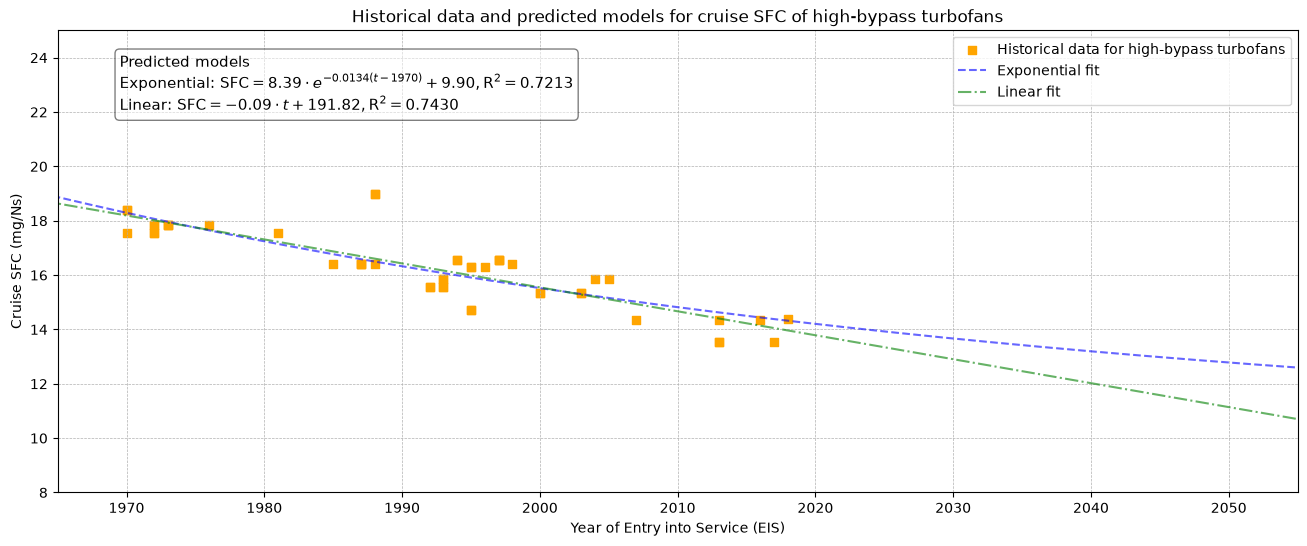

In [318]:
#Exponential model for curve fitting
t0 = np.min(EIS_rq)

def exp_model(t, a, b, c):
    return a * np.exp(-b * (t-t0)) + c

#Guesses for [a, b, c]
coefficent_guess = [5, 0.03, 11]
print(np.max(Engine_crs_SFC_rq)-np.min(Engine_crs_SFC_rq), 0.03, np.min(Engine_crs_SFC_rq))


# Fit the exponential model to the data
params, covariance = curve_fit(exp_model, EIS_rq, Engine_crs_SFC_rq, p0=coefficent_guess, maxfev=10000, bounds=([0, 0, 9.9], [15, 0.1, 12.5]))

print("Fitted parameters: a =", params[0], ", b =", params[1], ", c =", params[2])
print("Covariance matrix:\n", covariance)
years = np.linspace(1940, 2055, 300)
SFC_fit = exp_model(years, params[0], params[1], params[2])


#Linear fit for comparison
coefficients_deg1 = np.polyfit(EIS_rq, Engine_crs_SFC_rq, 1)
coefficients_deg3 = np.polyfit(EIS_rq, Engine_crs_SFC_rq, 3)

poly1d = np.poly1d(coefficients_deg1)
poly2d = np.poly1d(coefficients_deg3)

predicted_SFC_deg1 = poly1d(years)
predicted_SFC_deg3 = poly2d(years)



#Predicting SFC for 2050 using the fitted models
SFC_2050_exp = exp_model(2050, params[0], params[1], params[2])
SFC_2050_deg1 = poly1d(2050)
print(f"Predicted cruise SFC for 2050 using exponential fit: {SFC_2050_exp:.2f} mg/Ns")
print(f"Predicted cruise SFC for 2050 using linear fit: {SFC_2050_deg1:.2f} mg/Ns")

#Scale for loiter via factor from lecture notes. 
loiter_factor = 11.3/14.5
SFC_2050_loiter = SFC_2050_exp * loiter_factor
print(f"Predicted loiter SFC for 2050 using exponential fit: {SFC_2050_loiter:.2f} mg/Ns")



#RMSE and R^2 for the exponential fit
residuals = Engine_crs_SFC_rq - exp_model(np.array(EIS_rq), params[0], params[1], params[2])
rmse = np.sqrt(np.mean(residuals**2))
r2 = 1 - (np.sum(residuals**2) / np.sum((Engine_crs_SFC_rq - np.mean(Engine_crs_SFC_rq))**2))
print(f"Exponential fit RMSE: {rmse:.4f}, R^2: {r2:.4f}")

#RMSE and R^2 for the linear fit
residuals_deg1 = Engine_crs_SFC_rq - poly1d(np.array(EIS_rq))
rmse_deg1 = np.sqrt(np.mean(residuals_deg1**2))
r2_deg1 = 1 - (np.sum(residuals_deg1**2) / np.sum((Engine_crs_SFC_rq - np.mean(Engine_crs_SFC_rq))**2))
print(f"Linear fit RMSE: {rmse_deg1:.4f}, R^2: {r2_deg1:.4f}")

#Plotting the data and the fitted curves
fig, ax = plt.subplots(figsize=(16, 6))
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.set_xlabel("Year of Entry into Service (EIS)")
ax.set_ylabel("Cruise SFC (mg/Ns)")
ax.set_ylim(8, 25)
ax.set_xlim(1965, 2055)
scatter = ax.scatter(EIS_rq, Engine_crs_SFC_rq, marker='s', color='orange', label="Historical data for high-bypass turbofans")
ax.plot(years, SFC_fit, color='blue', label="Exponential fit", linestyle='--', alpha=0.6)
ax.plot(years, predicted_SFC_deg1, color='green', label="Linear fit", linestyle='-.', alpha=0.6)
ax.set_title("Historical data and predicted models for cruise SFC of high-bypass turbofans")
ax.legend()
eq_text = (
    "Predicted models\n"
    rf"Exponential: $\text{{SFC}} = {params[0]:.2f} \cdot e^{{-{params[1]:.4f}(t - {t0})}} + {params[2]:.2f},  \text{{R}}^2 = {r2:.4f}$" "\n"
    rf"Linear: $\text{{SFC}} = {coefficients_deg1[0]:.2f} \cdot t + {coefficients_deg1[1]:.2f},  \text{{R}}^2 = {r2_deg1:.4f}$"
)
ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

NumPy is working: True
